In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from src.utils import get_latest_file
from src.config import *
from src.modeling import *
from sklearn.metrics import classification_report, roc_auc_score

from datetime import datetime


# ## 1. Chargement des données

In [2]:
dataset_path = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)
df = pd.read_csv(dataset_path)

target = 'IS_WIN'


# On applique le même préprocessing que d'habitude
X = prepare_model_input(df, target=target, drop_odds=True, drop_player_absent=True, verbose=True)
y = df.loc[X.index, target]

# ## 2. Analyse de corrélation


In [3]:
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.99

high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > corr_threshold)]
print(f"Colonnes à retirer pour corrélation > {corr_threshold} : {len(high_corr_cols)}")

print(high_corr_cols)

X_reduced_corr = X.drop(columns=high_corr_cols)
y_reduced_corr = y.loc[X_reduced_corr.index]


Colonnes à retirer pour corrélation > 0.99 : 274
['ROLL_fieldGoalsMade_traditional_5', 'ROLL_fieldGoalsMade_traditional_10', 'ROLL_fieldGoalsAttempted_traditional_5', 'ROLL_fieldGoalsAttempted_traditional_10', 'ROLL_threePointersMade_traditional_5', 'ROLL_threePointersMade_traditional_50', 'ROLL_threePointersMade_traditional_100', 'ROLL_threePointersMade_traditional_200', 'ROLL_threePointersAttempted_traditional_5', 'ROLL_threePointersAttempted_traditional_10', 'ROLL_threePointersAttempted_traditional_25', 'ROLL_threePointersAttempted_traditional_50', 'ROLL_threePointersAttempted_traditional_100', 'ROLL_threePointersAttempted_traditional_200', 'ROLL_reboundsDefensive_traditional_5', 'ROLL_reboundsTotal_traditional_5', 'ROLL_points_traditional_5', 'ROLL_points_traditional_10', 'ROLL_points_traditional_25', 'ROLL_points_traditional_50', 'ROLL_points_traditional_100', 'ROLL_points_traditional_200', 'ROLL_MINUTES_PLAYED_5', 'ROLL_MINUTES_PLAYED_10', 'ROLL_pace_advanced_25', 'ROLL_pace_adva

# Bloc PCA – Réduction de dimension

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardisation indispensable avant PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced_corr)


# Lancement PCA : garder 95% de la variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ PCA terminé. Nombre de composantes conservées : {X_pca.shape[1]} (sur {X_reduced_corr.shape[1]} features)")


✅ PCA terminé. Nombre de composantes conservées : 147 (sur 1177 features)


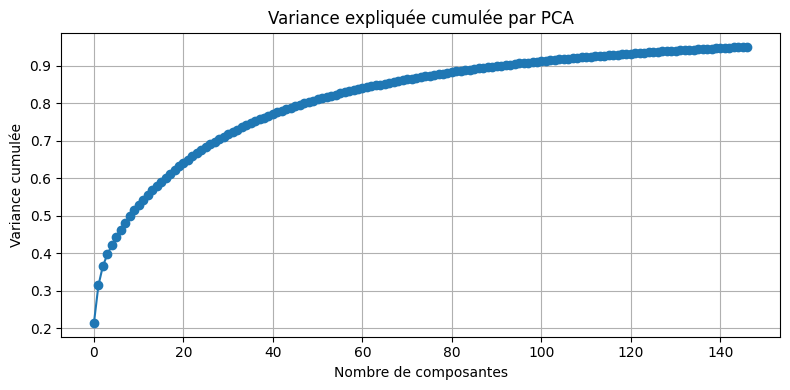

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Variance expliquée cumulée par PCA')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.grid(True)
plt.tight_layout()
plt.show()


# Split temporel : 80% des premières lignes pour entraînement, 20% dernières pour test

In [6]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_train, y_reduced_corr_test = train_test_split(
#     X_reduced_corr, y_reduced_corr, test_size=0.2, random_state=42
# )

# X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
#     X_pca, y_reduced_corr, test_size=0.2, random_state=42
# )

# split temporel

split_index = int(len(X_reduced_corr) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


X_reduced_corr_train = X_reduced_corr.iloc[:split_index]
X_reduced_corr_test = X_reduced_corr.iloc[split_index:]

y_reduced_corr_train = y_reduced_corr.iloc[:split_index]
y_reduced_corr_test = y_reduced_corr.iloc[split_index:]

X_train_pca = X_pca[:split_index]
X_test_pca = X_pca[split_index:]

y_train_pca = y_reduced_corr.iloc[:split_index]
y_test_pca = y_reduced_corr.iloc[split_index:]


# Visualisation de la distribution du target

In [7]:
# plt.figure(figsize=(6, 4))
# sns.countplot(x=y)
# plt.title("Répartition des classes (IS_WIN)")
# plt.show()


# Matrice de corrélation des features les plus importantes

In [8]:
# Matrice de corrélation des features nettoyées (top 20 en moyenne)
# top_cleaned = X_reduced_corr.mean().sort_values(ascending=False).head(500).index
# plt.figure(figsize=(30, 30))
# sns.heatmap(X_reduced_corr[top_cleaned].corr(), annot=False, fmt=".2f", cmap="coolwarm")
# plt.title("Corrélation des 20 features nettoyées les plus influentes")
# plt.tight_layout()
# plt.show()

# Entraînement LGBM


In [9]:
import lightgbm as lgb

def run_lgbm_eval(Xtr, ytr, Xte, yte, name):
    start_time = datetime.now()
    model = lgb.LGBMClassifier(n_estimators=200, random_state=42)
    _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
    metrics["train_time"] = (datetime.now() - start_time).total_seconds()
    return metrics

results_lgbm = [
    run_lgbm_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "LGBM_reduced"),
    run_lgbm_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "LGBM_PCA"),
    run_lgbm_eval(X_train, y_train, X_test, y_test, "LGBM_all"),
]

results_lgbm_df = pd.concat(results_lgbm, ignore_index=True)
display(results_lgbm_df)

[LightGBM] [Info] Number of positive: 24866, number of negative: 27756
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.218256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287196
[LightGBM] [Info] Number of data points in the train set: 52622, number of used features: 1177
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.472540 -> initscore=-0.109951
[LightGBM] [Info] Start training from score -0.109951
========= LGBM_reduced evaluation =========
[LightGBM] [Info] Number of positive: 24866, number of negative: 27756
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37485
[LightGBM] [Info] Number of data points in the train set: 52622, number of used features: 147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.472540 -> initscore=-0.109951
[LightGBM] [Info

/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


========= LGBM_PCA evaluation =========
[LightGBM] [Info] Number of positive: 24866, number of negative: 27756
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.307259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 351273
[LightGBM] [Info] Number of data points in the train set: 52622, number of used features: 1451
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.472540 -> initscore=-0.109951
[LightGBM] [Info] Start training from score -0.109951
========= LGBM_all evaluation =========


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,LGBM_reduced,0.631043,0.623775,0.658704,0.640764,0.682192,0.642291,3973,2611,2243,4329,13.872804
1,LGBM_PCA,0.625874,0.634059,0.593731,0.613233,0.673467,0.647613,4332,2252,2670,3902,1.512262
2,LGBM_all,0.629599,0.624178,0.649726,0.636696,0.678108,0.645877,4013,2571,2302,4270,16.855460


## Test CatBoost


In [10]:
from catboost import CatBoostClassifier


def run_catboost_eval(Xtr, ytr, Xte, yte, name):
    start_time = datetime.now()
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        random_seed=42,
        verbose=0
    )
    _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
    metrics["train_time"] = (datetime.now() - start_time).total_seconds()
    return metrics

results_catboost = [
    run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
    run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
    run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
]

results_catboost_df = pd.concat(results_catboost, ignore_index=True)
display(results_catboost_df)

========= CatBoost_reduced evaluation =========
========= CatBoost_PCA evaluation =========
========= CatBoost_all evaluation =========


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,CatBoost_reduced,0.639176,0.635366,0.651704,0.643431,0.695593,0.632070,4126,2458,2289,4283,15.904049
1,CatBoost_PCA,0.620857,0.643012,0.541844,0.588109,0.672128,0.647521,4607,1977,3011,3561,5.156012
2,CatBoost_all,0.636820,0.629437,0.663725,0.646126,0.695461,0.631781,4016,2568,2210,4362,18.940925


# XGBoost

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


def run_xgboost_eval(Xtr, ytr, Xte, yte, name):
    start_time = datetime.now()
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
    metrics["train_time"] = (datetime.now() - start_time).total_seconds()
    return metrics

results_xgboost = [
    run_xgboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "XGB_reduced"),
    run_xgboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "XGB_PCA"),
    run_xgboost_eval(X_train, y_train, X_test, y_test, "XGB_all"),
]

results_xgboost_df = pd.concat(results_xgboost, ignore_index=True)
display(results_xgboost_df)

/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:32:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGB_reduced evaluation =========


/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:33:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGB_PCA evaluation =========


/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:33:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGB_all evaluation =========


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,XGB_reduced,0.636744,0.629946,0.661290,0.645238,0.687728,0.636554,4031,2553,2226,4346,61.896023
1,XGB_PCA,0.623062,0.640726,0.558734,0.596928,0.674724,0.646273,4525,2059,2900,3672,6.060639
2,XGB_all,0.638492,0.627887,0.678332,0.652136,0.689325,0.636893,3942,2642,2114,4458,72.752415


In [12]:
# print results of all models

display(results_lgbm_df)
display(results_catboost_df)
display(results_xgboost_df)




,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,LGBM_reduced,0.631043,0.623775,0.658704,0.640764,0.682192,0.642291,3973,2611,2243,4329,13.872804
1,LGBM_PCA,0.625874,0.634059,0.593731,0.613233,0.673467,0.647613,4332,2252,2670,3902,1.512262
2,LGBM_all,0.629599,0.624178,0.649726,0.636696,0.678108,0.645877,4013,2571,2302,4270,16.855460


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,CatBoost_reduced,0.639176,0.635366,0.651704,0.643431,0.695593,0.632070,4126,2458,2289,4283,15.904049
1,CatBoost_PCA,0.620857,0.643012,0.541844,0.588109,0.672128,0.647521,4607,1977,3011,3561,5.156012
2,CatBoost_all,0.636820,0.629437,0.663725,0.646126,0.695461,0.631781,4016,2568,2210,4362,18.940925


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,XGB_reduced,0.636744,0.629946,0.661290,0.645238,0.687728,0.636554,4031,2553,2226,4346,61.896023
1,XGB_PCA,0.623062,0.640726,0.558734,0.596928,0.674724,0.646273,4525,2059,2900,3672,6.060639
2,XGB_all,0.638492,0.627887,0.678332,0.652136,0.689325,0.636893,3942,2642,2114,4458,72.752415


## Calibration des probabilités


In [13]:
# from sklearn.calibration import calibration_curve
# import matplotlib.pyplot as plt

# prob_true, prob_pred = calibration_curve(y_test, probas, n_bins=10)
# plt.plot(prob_pred, prob_true, marker='o')
# plt.plot([0,1],[0,1], linestyle='--', color='gray')
# plt.xlabel('Predicted probability')
# plt.ylabel('True probability in each bin')
# plt.title('Calibration Curve')
# plt.show()

# # same for reduced features
# prob_true_reduced, prob_pred_reduced = calibration_curve(y_reduced_corr_test, probas_reduced, n_bins=10)
# plt.plot(prob_pred_reduced, prob_true_reduced, marker='o')
# plt.plot([0,1],[0,1], linestyle='--', color='gray')
# plt.xlabel('Predicted probability')
# plt.ylabel('True probability in each bin')
# plt.title('Calibration Curve (Reduced Features)')
# plt.show()


# ## 3. Feature importance - LGBM


In [14]:

# # ## 3. Feature importance - LGBM
# model = LGBMClassifier(n_estimators=150, random_state=42)
# model.fit(X_reduced_corr, y)

# importances = pd.Series(model.feature_importances_, index=X_reduced_corr.columns)
# top_features = importances.sort_values(ascending=False).head(50)

# plt.figure(figsize=(10, 15))
# top_features.plot(kind='barh')
# plt.title("Top 50 Feature Importances (LGBM)")
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()


# #catboost feature importance

# importances_cat = pd.Series(cat.get_feature_importance(), index=X_reduced_corr.columns)
# top_features_cat = importances_cat.sort_values(ascending=False).head(50)
# plt.figure(figsize=(10, 15))
# top_features_cat.plot(kind='barh')
# plt.title("Top 50 Feature Importances (CatBoost)")
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()


# ## 4. Permutation Importance (optionnel et coûteux)


In [15]:
# X_train, X_test, y_train, y_test = train_test_split(X_reduced_corr, y, test_size=0.3, random_state=42)
# perm_model = LGBMClassifier(n_estimators=150, random_state=42)
# perm_model.fit(X_train, y_train)

# perm = permutation_importance(perm_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
# sorted_idx = perm.importances_mean.argsort()[::-1][:25]

# plt.figure(figsize=(12, 6))
# plt.barh(range(25), perm.importances_mean[sorted_idx])
# plt.yticks(range(25), X_test.columns[sorted_idx])
# plt.title("Top 25 Features - Permutation Importance")
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()


# ## 5. Sauvegarde de la liste des features retenues


In [16]:

# features_to_keep = top_features.index.tolist()
# with open("selected_features_lgbm_top50.txt", "w") as f:
#     for feat in features_to_keep:
#         f.write(f"{feat}\n")

# print("✅ Feature cleaning terminé. Liste enregistrée dans selected_features_lgbm_top50.txt")


# GridSearchCV et RandomizedSearchCV pour CatBoostClassifier

In [17]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cat = CatBoostClassifier(verbose=0, random_seed=42)

cat_param_grid = {
    'depth': [4, 5, 6, 7],
    'iterations': [200, 400, 600],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_cat = GridSearchCV(
    estimator=cat,
    param_grid=cat_param_grid,
    scoring='roc_auc',
    cv=tscv,
    n_jobs=1,  # ⚠️ met à 1 pour ne pas charger le GPU depuis plusieurs threads
    verbose=2
)

grid_cat.fit(X_train, y_train)

print("📊 Best CatBoost params:", grid_cat.best_params_)
print("🏆 Best CatBoost ROC AUC (CV):", grid_cat.best_score_)


Fitting 3 folds for each of 432 candidates, totalling 1296 fits
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.01; total time=   2.5s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.01; total time=   3.5s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.01; total time=   4.6s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.03; total time=   2.4s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.03; total time=   3.6s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.03; total time=   4.6s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.05; total time=   2.4s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.05; total time=   3.7s
[CV] END border_count=32, depth=4, iterations=200, l2_leaf_reg=1, learning_rate=0.05; total time

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

param_dist = {
    'depth': [4, 5, 6, 7],
    'iterations': [200, 400, 600],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

cat = CatBoostClassifier(verbose=0, random_seed=42)

random_search = RandomizedSearchCV(
    cat,
    param_distributions=param_dist,
    n_iter=50,  # ← à ajuster selon temps dispo
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# X_train, y_train, X_test, y_test

random_search.fit(X_train, y_train)

print("📊 Best CatBoost params:", random_search.best_params_)
print("🏆 Best CatBoost ROC AUC (CV):", random_search.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END border_count=64, depth=5, iterations=200, l2_leaf_reg=1, learning_rate=0.01; total time= 2.1min
[CV] END border_count=64, depth=5, iterations=200, l2_leaf_reg=1, learning_rate=0.01; total time= 2.4min
[CV] END border_count=32, depth=6, iterations=200, l2_leaf_reg=3, learning_rate=0.01; total time= 2.5min
[CV] END border_count=32, depth=6, iterations=200, l2_leaf_reg=3, learning_rate=0.01; total time= 2.5min
[CV] END border_count=64, depth=5, iterations=200, l2_leaf_reg=1, learning_rate=0.01; total time= 2.5min
[CV] END border_count=32, depth=6, iterations=200, l2_leaf_reg=3, learning_rate=0.01; total time= 2.6min
[CV] END border_count=64, depth=4, iterations=200, l2_leaf_reg=7, learning_rate=0.03; total time= 2.0min
[CV] END border_count=32, depth=4, iterations=600, l2_leaf_reg=5, learning_rate=0.01; total time= 5.2min
[CV] END border_count=32, depth=4, iterations=600, l2_leaf_reg=5, learning_rate=0.01; total time= 

# GridSearchCV et RandomizedSearchCV pour XGBClassifier

In [19]:
# from scipy.stats import uniform, randint

# param_distributions = {
#     'n_estimators': randint(100, 1000),
#     'max_depth': randint(3, 10),
#     'learning_rate': uniform(0.01, 0.3),
#     'subsample': uniform(0.6, 0.4),
#     'colsample_bytree': uniform(0.6, 0.4),
#     'gamma': uniform(0, 0.5),
#     'reg_alpha': uniform(0, 1),
#     'reg_lambda': uniform(0, 1)
# }

# from sklearn.model_selection import RandomizedSearchCV
# from xgboost import XGBClassifier

# xgb_model = XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='auc',
#     use_label_encoder=False,
#     random_state=42
# )

# random_search = RandomizedSearchCV(
#     estimator=xgb_model,
#     param_distributions=param_distributions,
#     n_iter=30,
#     scoring='roc_auc',
#     cv=3,
#     verbose=1,
#     n_jobs=4,
#     random_state=42
# )

# random_search.fit(X_reduced_corr_train, y_reduced_corr_train)

# from sklearn.metrics import classification_report, roc_auc_score

# best_model = random_search.best_estimator_
# y_pred = best_model.predict(X_reduced_corr_test)
# y_proba = best_model.predict_proba(X_reduced_corr_test)[:, 1]

# print(classification_report(y_reduced_corr_test, y_pred))
# print("ROC AUC:", roc_auc_score(y_reduced_corr_test, y_proba))

